# **EXPLORATION**

## Libraries

In [1]:
import sys
import os
import pandas as pd

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from utils import *
from visualizations import *

## Data

In [2]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [3]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [4]:
dataset = dataset_original.copy()

## 1. Dataset Structure & Integrity

In [5]:
# TODO: How many reviews?
dataset.shape[0]

53566

In [6]:
# TODO: How many unique restaurants are there?
dataset['title'].nunique()

295

In [7]:
# TODO: Are there missing records?
dataset.isnull().sum()

title              0
categoryName       0
website         2966
url                0
reviewsCount       0
stars              0
text               0
dtype: int64

In [8]:
missing_website_rows = dataset[dataset['website'].isnull()]
print(f"Number of rows with missing website: {len(missing_website_rows)}")
missing_website_rows[['title', 'categoryName', 'website', 'url', 'stars']].head(10)
restaurants_missing_website = missing_website_rows['title'].unique()
restaurants_missing_website

Number of rows with missing website: 2966


array(['Egg Harbor Cafe', 'Mi Barrio Mexican Restaurant',
       'Jalisco Restaurant', 'J.A.T.C Cuisine ATL',
       'The Courtside Grille', 'Little Thai Cuisine',
       'Savor Bar & Kitchen', 'Cinco Mexican Cantina', "Farmer's Basket",
       'Marisqueria El Escandalo', 'Smokey Q BBQ', 'El Rio Cantina',
       'Mexican Grill', 'Balsas Mexican Restaurant', 'LA MEXICANA',
       'PITA Mediterranean Street Food', 'Big Daddy’s Oyster Bar',
       'The Terrace', 'Padella Italian Atlanta', 'Mi Rancho #2',
       'Marietta Crawfish', 'Philly & Wraps',
       'PITA Mediterranean Street Food-Marietta Square', 'MamiTaco',
       'Costa Mar Seafood & Grill', 'Ege Sushi & Japanese Cuisine'],
      dtype=object)

In [9]:
# Check if restaurants are completely missing website information
# or if they only have missing websites for some of their reviews
print("Restaurants that have NO website information across ALL their reviews:")

for rest in restaurants_missing_website:
    total_reviews = dataset[dataset['title'] == rest].shape[0]
    missing_website_count = dataset[dataset['title'] == rest]['website'].isnull().sum()
    
    if total_reviews == missing_website_count:
        print(f"- {rest}")

print("\nConclusion: All restaurants listed above have NO website information in any of their reviews.")
print("This suggests these restaurants either don't have websites or the website data wasn't available during scraping.")

Restaurants that have NO website information across ALL their reviews:
- Egg Harbor Cafe
- Mi Barrio Mexican Restaurant
- Jalisco Restaurant
- J.A.T.C Cuisine ATL
- The Courtside Grille
- Little Thai Cuisine
- Savor Bar & Kitchen
- Cinco Mexican Cantina
- Farmer's Basket
- Marisqueria El Escandalo
- Smokey Q BBQ
- El Rio Cantina
- Mexican Grill
- Balsas Mexican Restaurant
- LA MEXICANA
- PITA Mediterranean Street Food
- Big Daddy’s Oyster Bar
- The Terrace
- Padella Italian Atlanta
- Mi Rancho #2
- Marietta Crawfish
- Philly & Wraps
- PITA Mediterranean Street Food-Marietta Square
- MamiTaco
- Costa Mar Seafood & Grill
- Ege Sushi & Japanese Cuisine

Conclusion: All restaurants listed above have NO website information in any of their reviews.
This suggests these restaurants either don't have websites or the website data wasn't available during scraping.


In [10]:
# TODO: Are there duplicated records?
dataset.duplicated().sum()

99

In [11]:
# show total number of duplicated rows (excluding the first occurrence)
total_dup = dataset.duplicated().sum()
print(f"Total duplicated rows (excluding first occurrence): {total_dup}")

# Also check duplicates based on title + text (useful to find identical reviews)
dup_review_text = dataset[dataset.duplicated(subset=['text'], keep=False)].reset_index(drop=True)
print(f"Rows duplicated on review text: {len(dup_review_text)}")
display(dup_review_text.head(5))

Total duplicated rows (excluding first occurrence): 99
Rows duplicated on review text: 2607


,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Great place.
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Simply amazing
2,Nino's Italian Restaurant,Italian restaurant,https://ninosatlanta.com/?y_source=1_MTQxNzM5N...,https://www.google.com/maps/place/Nino's+Itali...,643,5.0,Food was good.
3,Nino's Italian Restaurant,Italian restaurant,https://ninosatlanta.com/?y_source=1_MTQxNzM5N...,https://www.google.com/maps/place/Nino's+Itali...,643,5.0,Fast service.
4,El Valle,Mexican restaurant,http://valleatl.com/,https://www.google.com/maps/place/El+Valle/@33...,391,5.0,Delicious food.


## 2. Restaurants

In [12]:
# TODO: How many unique restaurants?
dataset['title'].nunique()

295

In [13]:
# TODO: Which restaurants do we have?
dataset['title'].unique()

array(['The Optimist', "Nino's Italian Restaurant", 'El Valle',
       'Longleaf Restaurant', 'Benihana', "Mama's Restaurant",
       'Dirty Rascal', 'Chick-fil-A', 'KR SteakBar',
       'The Bistro – Eat. Drink. Connect.®', 'Johnny Rockets',
       'Grindhouse Killer Burgers', '5Church Buckhead', 'Egg Harbor Cafe',
       'El Azteca', 'Mi Barrio Mexican Restaurant', 'Grana',
       'Fork & Juniper Restaurant', 'NaanStop', 'Yard House', 'Atalian',
       'TWO urban licks', 'Aria', 'Miller Union', 'No Mas! Cantina',
       "Houston's", 'Staplehouse', 'Alma Cocina Downtown', 'Atlas',
       'Aviva by Kameel Downtown', 'La Grotta Ristorante',
       'Nan Thai Fine Dining', 'La Tavola Trattoria', 'Bacchanalia',
       'Bones Restaurant', 'Canoe', 'Old Lady Gang Southern Cuisine',
       'Jalisco Restaurant', "Fat Matt's Rib Shack",
       'Bangkok Thai Restaurant', 'BrickStone Cafe & Restaurant',
       'Argosy', 'Atlanta Fish Market',
       'Six Feet Under Pub & Fish House - Grant Park',

In [14]:
# TODO: How many reviews per restaurant?

# Count how many reviews each restaurant has *in the dataset*
analyzed_counts = dataset['title'].value_counts().rename("Analyzed Reviews")

# Get the total number of reviews each restaurant had at scraping time
total_counts = dataset.groupby('title')['reviewsCount'].first().rename("Total Reviews")

# Combine both into a single DataFrame
total_reviews_comparison = (
    pd.concat([total_counts, analyzed_counts], axis=1)
    .reset_index()
    .rename(columns={'index': 'Restaurant'})
)

total_reviews_comparison['Difference'] = total_reviews_comparison['Total Reviews'] - total_reviews_comparison['Analyzed Reviews']
total_reviews_comparison['% Analyzed'] = (total_reviews_comparison['Analyzed Reviews'] / total_reviews_comparison['Total Reviews'] * 100).round(2)
total_reviews_comparison.sort_values(by='Total Reviews', ascending=False).head(10)

,Restaurant,Total Reviews,Analyzed Reviews,Difference,% Analyzed
210,Pappadeaux Seafood Kitchen,13268,191,13077,1.44
199,Old Lady Gang Southern Cuisine,9933,80,9853,0.81
252,TWO urban licks,8057,22,8035,0.27
239,Six Feet Under Pub & Fish House - Grant Park,6817,34,6783,0.50
194,No Mas! Cantina,6300,69,6231,1.10
105,Hard Rock Cafe,6144,61,6083,0.99
11,Atlanta Fish Market,6017,32,5985,0.53
85,Fat Matt's Rib Shack,5516,60,5456,1.09
22,Benihana,5504,85,5419,1.54
290,Yard House,4641,59,4582,1.27


In [15]:
# TODO: Clustered Bar plot: reviews per restaurant (sorted descending — maybe top 20) (2 bars per restaurant -> total reviews (reviewsCount) + total reviews analysed (sum of reviews per restaurant)).
clustered_bar_charts(
    data=total_reviews_comparison,
    x='Restaurant',
    y_columns=['Total Reviews', 'Analyzed Reviews'],
    title='Reviews per Restaurant: Total vs Analyzed',
    labels={'Restaurant': 'Restaurant Name', 'Total Reviews': 'Total Reviews', 'Analyzed Reviews': 'Analyzed Reviews'},
    top=5)

In [16]:
# TODO: Restaurants with multiple categories.

more_than_1_category = pd.DataFrame(
    dataset.groupby('title')['categoryName'].nunique()
            .sort_values(ascending=False)
).reset_index()

more_than_1_category.columns = ['Restaurant', 'Number of Categories']
more_than_1_category[more_than_1_category['Number of Categories'] != 1]


,Restaurant,Number of Categories
0,J. Christopher's,2


In [17]:
dataset[dataset['title'] == "J. Christopher's"]['categoryName'].unique()

array(['Breakfast restaurant', 'American restaurant'], dtype=object)

## 3. Cuisine Types (categoryName)

In [18]:
# TODO: How many unique categories?
dataset['categoryName'].nunique()

19

In [19]:
# TODO: Which categories do we have?
dataset['categoryName'].unique()

array(['Seafood restaurant', 'Italian restaurant', 'Mexican restaurant',
       'New American restaurant', 'Japanese restaurant',
       'Fast food restaurant', 'American restaurant',
       'Hamburger restaurant', 'Breakfast restaurant',
       'Indian restaurant', 'Mediterranean restaurant', 'Thai restaurant',
       'Steak house', 'Barbecue restaurant', 'Bar & grill',
       'Chinese restaurant', 'Pizza restaurant', 'Chicken restaurant',
       'Sandwich shop'], dtype=object)

In [20]:
# TODO: How many restaurants per category?
restaurants_per_category = dataset['title'].groupby(dataset['categoryName']).nunique().reset_index()
restaurants_per_category.columns = ['Category', 'Number of Restaurants']
restaurants_per_category = restaurants_per_category.sort_values(by='Number of Restaurants', ascending=False)
restaurants_per_category

bar_chart(restaurants_per_category, 'Category', 'Number of Restaurants', 'Number of Restaurants per Category', labels={'Number of Restaurants': 'Number of Restaurants', 'Category': 'Category'})

In [21]:
# TODO: See if there are meaningful patterns in website presence/absence across categories.

all_categories = pd.DataFrame(dataset['categoryName'].unique(), columns=['Category'])

category_website_info = (
    dataset[dataset['title'].isin(restaurants_missing_website)]
    [['title', 'categoryName']]
    .drop_duplicates()
    .groupby('categoryName')
    .nunique()
    .reset_index()
)

category_website_info.columns = ['Category', 'Number of Restaurants Missing Website']

category_website_info = all_categories.merge(
    category_website_info, on='Category', how='left'
).fillna(0).sort_values(by='Number of Restaurants Missing Website', ascending=False)

category_website_info['Number of Restaurants Missing Website'] = category_website_info['Number of Restaurants Missing Website'].astype(int)

category_website_info


,Category,Number of Restaurants Missing Website
2,Mexican restaurant,9
0,Seafood restaurant,3
6,American restaurant,3
10,Mediterranean restaurant,2
14,Bar & grill,2
3,New American restaurant,1
4,Japanese restaurant,1
5,Fast food restaurant,1
8,Breakfast restaurant,1
1,Italian restaurant,1


In [22]:
dataset[['categoryName', 'title']].value_counts().rename("Analyzed Reviews")

categoryName          title                                  
Fast food restaurant  Chick-fil-A                                1140
Breakfast restaurant  Waffle House                                852
Fast food restaurant  Wendy's                                     810
                      McDonald's                                  665
Chicken restaurant    Zaxby's Chicken Fingers & Buffalo Wings     588
                                                                 ... 
American restaurant   TWO urban licks                              22
                      The Bistro – Eat. Drink. Connect.®           16
                      The Terrace                                  16
Bar & grill           The Courtside Grille                         11
American restaurant   Fork & Juniper Restaurant                     8
Name: Analyzed Reviews, Length: 296, dtype: int64

In [23]:
# TODO: How many reviews per category?

# Count how many reviews each category has *in the dataset*
analyzed_counts = dataset[['categoryName', 'title']].value_counts().rename("Analyzed Reviews")
analyzed_counts = analyzed_counts.groupby('categoryName').sum()

# Get the total number of reviews each category had at scraping time
# First ensure we count each restaurant once (drop duplicate restaurant titles),
# then sum the reviewsCount per category.
total_counts = (
    dataset
    .drop_duplicates(subset=['categoryName', 'title'])
    .groupby('categoryName')['reviewsCount']
    .sum()
    .rename("Total Reviews")
)

# Combine both into a single DataFrame
total_reviews_per_category_comparison = (
    pd.concat([total_counts, analyzed_counts], axis=1)
    .reset_index()
    .rename(columns={'categoryName': 'Category'})
)

total_reviews_per_category_comparison['Difference'] = total_reviews_per_category_comparison['Total Reviews'] - total_reviews_per_category_comparison['Analyzed Reviews']
total_reviews_per_category_comparison['% Analyzed'] = (total_reviews_per_category_comparison['Analyzed Reviews'] / total_reviews_per_category_comparison['Total Reviews'] * 100).round(2)
total_reviews_per_category_comparison.sort_values(by='Total Reviews', ascending=False).head(10)

,Category,Total Reviews,Analyzed Reviews,Difference,% Analyzed
0,American restaurant,61277,5049,56228,8.24
12,Mexican restaurant,39920,8959,30961,22.44
16,Seafood restaurant,36064,2048,34016,5.68
9,Italian restaurant,23069,5108,17961,22.14
13,New American restaurant,20870,1903,18967,9.12
7,Hamburger restaurant,15097,1979,13118,13.11
14,Pizza restaurant,14949,4560,10389,30.50
6,Fast food restaurant,12998,5325,7673,40.97
17,Steak house,10211,1776,8435,17.39
10,Japanese restaurant,9234,1533,7701,16.60


In [24]:
# TODO: Clustered Bar plot: reviews per category (sorted descending — maybe top 20) (2 bars per category -> total reviews (reviewsCount) + total reviews analysed (sum of reviews per category)).
clustered_bar_charts(
    data=total_reviews_per_category_comparison,
    x='Category',
    y_columns=['Total Reviews', 'Analyzed Reviews'],
    title='Reviews per Category: Total vs Analyzed',
    labels={'Category': 'Category Name', 'Total Reviews': 'Total Reviews', 'Analyzed Reviews': 'Analyzed Reviews'},
    top=5)

In [25]:
# TODO: Which cuisines are most/least represented?

cuisine_counts = dataset.drop_duplicates(subset=['categoryName', 'title']).groupby('categoryName').nunique()['title']
cuisine_counts = cuisine_counts.sort_values(ascending=False).reset_index()
cuisine_counts.columns = ['Category', 'Number of Restaurants']
cuisine_counts
# also seen in the plot above, according to the analysed counts

,Category,Number of Restaurants
0,Mexican restaurant,52
1,American restaurant,36
2,Italian restaurant,30
3,Pizza restaurant,23
4,Chinese restaurant,16
5,Fast food restaurant,16
6,New American restaurant,15
7,Seafood restaurant,15
8,Hamburger restaurant,11
9,Indian restaurant,9


In [26]:
# TODO: Bar chart (horizontal) of restaurant count per category (sorted).
bar_chart(cuisine_counts, 'Category', 'Number of Restaurants', 'Number of Restaurants per Category', labels={'Number of Restaurants': 'Number of Restaurants', 'Category': 'Category'})

## 4. Ratings & Reviews

In [27]:
# TODO: What's the overall distribution of stars?
bar_chart(
    data=dataset['stars'].value_counts().reset_index().sort_values(by='index'),
    x='index',
    y='stars',
    title='Distribution of Star Ratings',
    labels={'index': 'Star Rating', 'stars': 'Number of Reviews'})

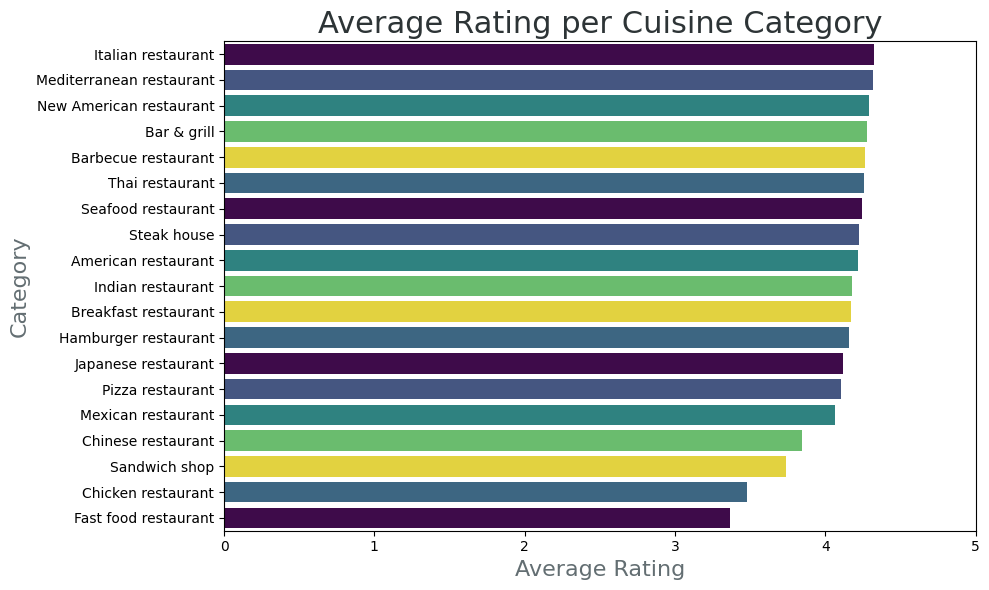

,categoryName,mean,median,count
9,Italian restaurant,4.322631,5.0,5108
11,Mediterranean restaurant,4.315172,5.0,1450
13,New American restaurant,4.291645,5.0,1903
1,Bar & grill,4.274616,5.0,1107
2,Barbecue restaurant,4.266023,5.0,1139
18,Thai restaurant,4.257143,5.0,1260
16,Seafood restaurant,4.246582,5.0,2048
17,Steak house,4.225788,5.0,1776
0,American restaurant,4.220440,5.0,5049
8,Indian restaurant,4.174558,5.0,1753


In [28]:
# TODO: Are there categories that systematically get higher/lower ratings?

category_rating_analysis(
    dataset=dataset,
    category_col='categoryName',
    rating_col='stars'
)


In [29]:
# TODO: Is there a relationship between reviewsCount and stars?
scatter_plot(
    data=dataset.drop_duplicates(subset=['categoryName', 'title']),
    x='reviewsCount',
    y='stars',
    title='Relationship between Reviews Count and Star Ratings',
    labels={'reviewsCount': 'Total Reviews Count', 'stars': 'Star Rating'}
)

ValueError: All arguments should have the same length. The length of argument `color` is 6, whereas the length of  previously-processed arguments ['reviewsCount', 'stars'] is 296

In [37]:
# TODO: Which restaurants have extreme ratings (5.0 or <3.0) and many reviews?

In [38]:
# TODO: See if there are meaningful patterns in website presence/absence across star ratings.

In [39]:
#TODO: Histogram / KDE of stars.

In [40]:
#TODO: Boxplot or violin plot: stars by categoryName.

In [41]:
#TODO: Scatter plot: reviewsCount vs stars (size = avg review length maybe).

In [42]:
# TODO: rating per category
dataset.groupby('categoryName')['stars'].describe()

,count,mean,std,min,25%,50%,75%,max
categoryName,,,,,,,,
American restaurant,5049.0,4.220440,1.308092,1.0,4.0,5.0,5.0,5.0
Bar & grill,1107.0,4.274616,1.226042,1.0,4.0,5.0,5.0,5.0
Barbecue restaurant,1139.0,4.266023,1.281337,1.0,4.0,5.0,5.0,5.0
Breakfast restaurant,2491.0,4.173826,1.344890,1.0,4.0,5.0,5.0,5.0
Chicken restaurant,1780.0,3.482022,1.700845,1.0,1.0,4.0,5.0,5.0
Chinese restaurant,2484.0,3.842593,1.554417,1.0,3.0,5.0,5.0,5.0
Fast food restaurant,5325.0,3.369014,1.696656,1.0,1.0,4.0,5.0,5.0
Hamburger restaurant,1979.0,4.156645,1.337686,1.0,4.0,5.0,5.0,5.0
Indian restaurant,1753.0,4.174558,1.376703,1.0,4.0,5.0,5.0,5.0


In [43]:
# TODO: rating per restaurant
dataset.groupby('title')['stars'].describe()

,count,mean,std,min,25%,50%,75%,max
title,,,,,,,,
3 Amigos Mexican Bar & Grill,182.0,4.549451,1.005661,1.0,5.0,5.0,5.0,5.0
5Church Buckhead,73.0,4.095890,1.396070,1.0,4.0,5.0,5.0,5.0
AG,62.0,4.500000,0.844461,2.0,4.0,5.0,5.0,5.0
ANNUNZIATA'S Pizza & Pasta,224.0,4.361607,1.335460,1.0,5.0,5.0,5.0,5.0
AZN Sandwich Bar,101.0,4.574257,0.973104,1.0,5.0,5.0,5.0,5.0
...,...,...,...,...,...,...,...,...
Yard House,59.0,3.830508,1.599057,1.0,2.5,5.0,5.0,5.0
Your Pie Pizza,386.0,4.349741,1.243983,1.0,4.0,5.0,5.0,5.0
Yume Ramen Bar in Peachtree City,215.0,4.013953,1.392500,1.0,3.0,5.0,5.0,5.0


In [44]:
# TODO: Where are the restaurants located? (url field)

## 5. Geographical Overview

In [45]:
# TODO: Do higher-rated categories cluster geographically?

In [46]:
# TODO: Folium or Plotly map: restaurants colored by rating or category.

In [47]:
# TODO: Density heatmap: concentration of restaurants across Atlanta.

## 6. Review Text Exploration

In [48]:
# TODO: What's the average review length?

In [49]:
# TODO: Are there obvious language issues or emojis/symbols?

In [50]:
# TODO: What are the most common words overall? By category?

In [51]:
# TODO: Word cloud of most frequent words.

In [52]:
# TODO: Bar plot of top 20 terms (using simple TF counts).

In [53]:
# TODO: Maybe a simple sentiment distribution (TextBlob/VADER) for curiosity — though deeper sentiment analysis will come later.